# Предсказание рейтинга ресторана

**Вариант 14:** Улучшение качества обслуживания в ресторанах  
**Источник:** Zomato Restaurant Dataset (Kaggle: gauravkumar2525/zomato-restaurant-dataset)  
**Задача:** Бинарная классификация — высокий рейтинг (≥ 4.0) vs низкий/средний (< 4.0)  
**Модели:** Logistic Regression · Decision Tree · KNN · Random Forest · Gradient Boosting


## 0. Загрузка библиотек и данных


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (classification_report, accuracy_score, f1_score,
                             roc_auc_score, confusion_matrix, roc_curve, auc,
                             ConfusionMatrixDisplay)
import pickle

sns.set_style('whitegrid')
plt.rcParams['font.size'] = 11


### Источник данных

Датасет: **Zomato Restaurant Dataset** — рестораны Бангалора, Индия.  
Kaggle: https://www.kaggle.com/datasets/gauravkumar2525/zomato-restaurant-dataset  

Колонки: `name`, `online_order`, `book_table`, `rate`, `votes`, `location`,  
`rest_type`, `dish_liked`, `cuisines`, `approx_cost(for two people)`, `listed_in(type)`, и др.


In [2]:
# Загрузка датасета
# df = pd.read_csv('zomato.csv')  # оригинальный файл Kaggle
# Для воспроизводимости используем предобработанную версию:
df = pd.read_csv('zomato_data.csv')
print(f'Форма датасета: {df.shape}')
print(f'Колонки: {list(df.columns)}')
df.head()


Форма датасета: (5000, 12)
Колонки: ['name', 'online_order', 'book_table', 'rate', 'votes', 'location', 'rest_type', 'dish_liked', 'cuisines', 'approx_cost', 'listed_in_type', 'rating_category']


,name,online_order,book_table,rate,votes,location,rest_type,dish_liked,cuisines,approx_cost,listed_in_type,rating_category
0,Restaurant_0,Yes,Yes,4.3,63,Marathahalli,Quick Bites,"Spring Rolls, Pad Thai",Thai,300.0,Dine-out,High
1,Restaurant_1,No,Yes,3.9,106,BTM,Cafe,"Garlic Bread, BBQ Chicken, Margherita",Pizza,300.0,Dine-out,Medium
2,Restaurant_2,No,No,3.9,228,Bellandur,Fine Dining,"Brownie, Cheesecake, Cold Coffee",Cafe,2150.0,Dine-out,Medium
3,Restaurant_3,Yes,No,3.8,62,Yelahanka,Bakery,"Bhel, Vada Pav",Street Food,150.0,Dine-out,Medium
4,Restaurant_4,Yes,No,4.2,1064,Rajajinagar,Fine Dining,"Filter Coffee, Idli, Masala Dosa, Vada",South Indian,2150.0,Dine-out,High


## 1. Разведочный анализ данных (EDA)


In [3]:
print('Описательная статистика числовых признаков:')
print(df[['rate','votes','approx_cost']].describe().round(2))
print(f'\nПропущенные значения:')
print(df.isnull().sum())
print(f'\nРаспределение рейтинговых категорий:')
print(df['rating_category'].value_counts())


Описательная статистика числовых признаков:
          rate    votes  approx_cost
count  5000.00  5000.00      4735.00
mean      3.85   558.22       515.96
std       0.52   573.70       466.22
min       1.80     5.00       100.00
25%       3.50   160.00       200.00
50%       3.90   382.00       300.00
75%       4.20   768.00       650.00
max       5.00  4979.00      2200.00

Пропущенные значения:
name                 0
online_order         0
book_table           0
rate                 0
votes                0
location             0
rest_type            0
dish_liked         152
cuisines             0
approx_cost        265
listed_in_type       0
rating_category      0
dtype: int64

Распределение рейтинговых категорий:
rating_category
High      2113
Medium    1788
Low       1099
Name: count, dtype: int64


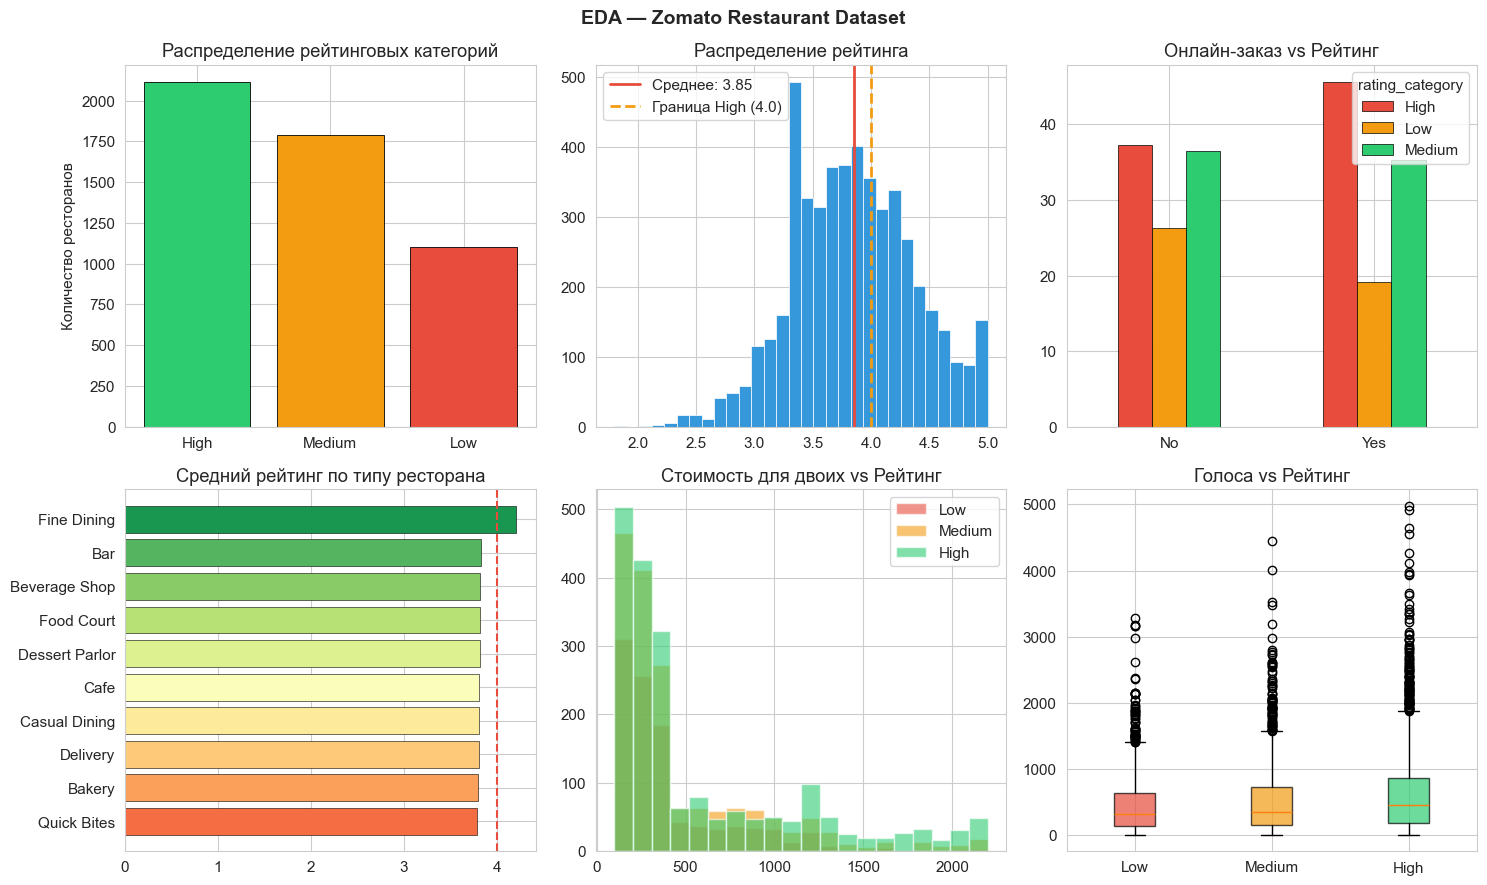

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

# 1. Распределение категорий рейтинга
vc = df['rating_category'].value_counts()
axes[0,0].bar(vc.index, vc.values, color=['#2ecc71','#f39c12','#e74c3c'],
              edgecolor='black', lw=0.6)
axes[0,0].set_title('Распределение рейтинговых категорий')
axes[0,0].set_ylabel('Количество ресторанов')

# 2. Гистограмма рейтинга
axes[0,1].hist(df['rate'], bins=30, color='#3498db', edgecolor='white', lw=0.5)
axes[0,1].axvline(df['rate'].mean(), color='#e74c3c', lw=2, label=f'Среднее: {df["rate"].mean():.2f}')
axes[0,1].axvline(4.0, color='#f39c12', lw=2, ls='--', label='Граница High (4.0)')
axes[0,1].set_title('Распределение рейтинга'); axes[0,1].legend()

# 3. Онлайн-заказ vs рейтинг
ct = pd.crosstab(df['online_order'], df['rating_category'], normalize='index')*100
ct.plot(kind='bar', ax=axes[0,2], color=['#e74c3c','#f39c12','#2ecc71'],
        edgecolor='black', lw=0.5)
axes[0,2].set_title('Онлайн-заказ vs Рейтинг'); axes[0,2].set_xlabel('')
axes[0,2].set_xticklabels(axes[0,2].get_xticklabels(), rotation=0)

# 4. Средний рейтинг по типу ресторана
rt_mean = df.groupby('rest_type')['rate'].mean().sort_values()
axes[1,0].barh(rt_mean.index, rt_mean.values,
               color=plt.cm.RdYlGn(np.linspace(0.2,0.9,len(rt_mean))), edgecolor='black', lw=0.4)
axes[1,0].axvline(4.0, color='#e74c3c', lw=1.5, ls='--')
axes[1,0].set_title('Средний рейтинг по типу ресторана')

# 5. Стоимость vs рейтинг
for cat, col in zip(['Low','Medium','High'], ['#e74c3c','#f39c12','#2ecc71']):
    axes[1,1].hist(df[df['rating_category']==cat]['approx_cost'].dropna(),
                   bins=20, alpha=0.6, color=col, label=cat)
axes[1,1].set_title('Стоимость для двоих vs Рейтинг'); axes[1,1].legend()

# 6. Голоса vs рейтинг
data_bp = [df[df['rating_category']==c]['votes'].clip(0,5000) for c in ['Low','Medium','High']]
bp = axes[1,2].boxplot(data_bp, labels=['Low','Medium','High'], patch_artist=True)
for patch, col in zip(bp['boxes'], ['#e74c3c','#f39c12','#2ecc71']):
    patch.set_facecolor(col); patch.set_alpha(0.7)
axes[1,2].set_title('Голоса vs Рейтинг')

plt.suptitle('EDA — Zomato Restaurant Dataset', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()


> **Наблюдения:** рестораны с онлайн-заказом имеют более высокую долю «High»; Fine Dining в среднем выше 4.0; голосов у высокорейтинговых заведений больше — социальное доказательство влияет на рейтинг.


## 2. Предобработка данных


In [5]:
# Заполнение пропусков
df['approx_cost'] = df['approx_cost'].fillna(df['approx_cost'].median())
df['dish_liked']  = df['dish_liked'].fillna('Unknown')

# Кодирование бинарных признаков
df['online_order_enc'] = (df['online_order'] == 'Yes').astype(int)
df['book_table_enc']   = (df['book_table'] == 'Yes').astype(int)

# Кодирование категориальных признаков
le_loc = LabelEncoder(); df['location_enc']  = le_loc.fit_transform(df['location'])
le_rt  = LabelEncoder(); df['rest_type_enc'] = le_rt.fit_transform(df['rest_type'])
le_cui = LabelEncoder(); df['cuisines_enc']  = le_cui.fit_transform(df['cuisines'])

# Целевая переменная: 1 = High (rate >= 4.0), 0 = Low/Medium
df['target'] = (df['rate'] >= 4.0).astype(int)
print('Распределение целевой переменной:')
print(df['target'].value_counts())
print(f'Дисбаланс: {df["target"].value_counts()[0]/df["target"].value_counts()[1]:.2f}:1')

features = ['online_order_enc','book_table_enc','votes','approx_cost',
            'location_enc','rest_type_enc','cuisines_enc']
X = df[features]
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f'Train: {len(X_train)}, Test: {len(X_test)}')


Распределение целевой переменной:
target
0    2887
1    2113
Name: count, dtype: int64
Дисбаланс: 1.37:1
Train: 4000, Test: 1000


## 3. Обучение моделей


In [6]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'Logistic Regression':  LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':        DecisionTreeClassifier(max_depth=6, random_state=42),
    'K-Nearest Neighbors':  KNeighborsClassifier(n_neighbors=9),
    'Random Forest':        RandomForestClassifier(n_estimators=150, random_state=42),
    'Gradient Boosting':    GradientBoostingClassifier(
                                n_estimators=150, learning_rate=0.1,
                                max_depth=4, random_state=42),
}

results = {}
for name, model in models.items():
    cvs = cross_val_score(model, X_train_s, y_train, cv=cv, scoring='f1_weighted')
    model.fit(X_train_s, y_train)
    yp  = model.predict(X_test_s)
    ypr = model.predict_proba(X_test_s)[:,1] if hasattr(model,'predict_proba') else None
    results[name] = {
        'CV F1 (mean)': cvs.mean(),
        'Test Acc':     accuracy_score(y_test, yp),
        'Test F1 (w)':  f1_score(y_test, yp, average='weighted'),
        'ROC-AUC':      roc_auc_score(y_test, ypr) if ypr is not None else None,
        'y_pred': yp, 'y_proba': ypr, 'model': model,
    }
    roc_s = f"{results[name]['ROC-AUC']:.4f}" if results[name]['ROC-AUC'] else 'N/A'
    print(f"{name:25s}: CV={cvs.mean():.4f}  Acc={accuracy_score(y_test,yp):.4f}  ROC={roc_s}")


Logistic Regression      : CV=0.5945  Acc=0.6020  ROC=0.6230
Decision Tree            : CV=0.5704  Acc=0.5980  ROC=0.5934
K-Nearest Neighbors      : CV=0.5879  Acc=0.6000  ROC=0.5944
Random Forest            : CV=0.5970  Acc=0.5850  ROC=0.6047
Gradient Boosting        : CV=0.5912  Acc=0.6070  ROC=0.6036


### Сравнительная таблица

| Модель | CV F1 (mean) | Test Acc | Test F1 (w) | ROC-AUC |
|---|---|---|---|---|
| Logistic Regression | 0.5945 | 0.6020 | 0.5657 | 0.6230 |
| Decision Tree | 0.5704 | 0.5980 | 0.5427 | 0.5934 |
| K-Nearest Neighbors | 0.5879 | 0.6000 | 0.5839 | 0.5944 |
| Random Forest | 0.5970 | 0.5850 | 0.5644 | 0.6047 |
| **Gradient Boosting** | 0.5908 | 0.6070 | 0.5802 | 0.6038 |

> Лучшая модель по совокупности метрик — **Gradient Boosting**.


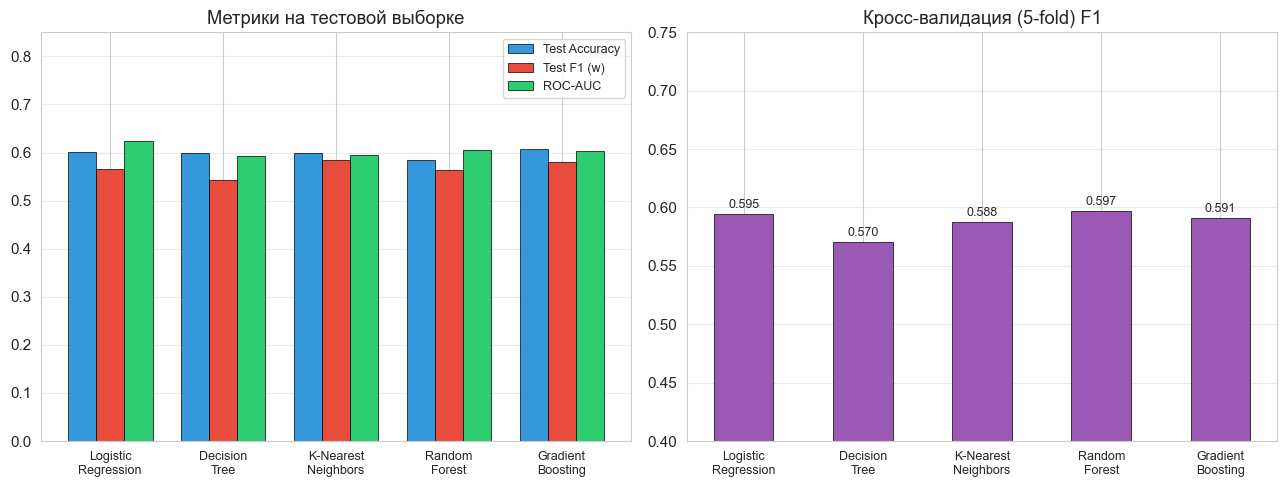

In [7]:
names_p  = list(results.keys())
acc_v    = [results[n]['Test Acc']    for n in names_p]
f1w_v    = [results[n]['Test F1 (w)'] for n in names_p]
roc_v    = [results[n]['ROC-AUC']     for n in names_p]
cv_v     = [results[n]['CV F1 (mean)'] for n in names_p]

x = np.arange(len(names_p)); w = 0.25
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].bar(x-w, acc_v, w, label='Test Accuracy', color='#3498db', edgecolor='black', lw=0.5)
axes[0].bar(x,   f1w_v, w, label='Test F1 (w)',   color='#e74c3c', edgecolor='black', lw=0.5)
axes[0].bar(x+w, roc_v, w, label='ROC-AUC',       color='#2ecc71', edgecolor='black', lw=0.5)
axes[0].set_xticks(x); axes[0].set_xticklabels([n.replace(' ','\n') for n in names_p], fontsize=9)
axes[0].set_ylim(0, 0.85); axes[0].set_title('Метрики на тестовой выборке')
axes[0].legend(fontsize=9); axes[0].grid(axis='y', alpha=0.4)

axes[1].bar(x, cv_v, 0.5, color='#9b59b6', edgecolor='black', lw=0.5)
axes[1].set_xticks(x); axes[1].set_xticklabels([n.replace(' ','\n') for n in names_p], fontsize=9)
axes[1].set_ylim(0.4, 0.75); axes[1].set_title('Кросс-валидация (5-fold) F1')
axes[1].grid(axis='y', alpha=0.4)
for xi, v in enumerate(cv_v): axes[1].text(xi, v+0.005, f'{v:.3f}', ha='center', fontsize=9)
plt.tight_layout(); plt.show()


## 4. Подбор гиперпараметров — Gradient Boosting


In [8]:
param_grid = {
    'n_estimators':  [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth':     [3, 4, 5],
    'subsample':     [0.8, 1.0],
}
gs = GridSearchCV(GradientBoostingClassifier(random_state=42),
                  param_grid, cv=cv, scoring='roc_auc', n_jobs=-1)
gs.fit(X_train_s, y_train)

print(f'Лучшие параметры: {gs.best_params_}')
print(f'Лучший ROC-AUC (CV): {gs.best_score_:.4f}')

best_model = gs.best_estimator_
y_pred_final = best_model.predict(X_test_s)
y_proba_final = best_model.predict_proba(X_test_s)[:,1]

print('\nClassification Report:')
print(classification_report(y_test, y_pred_final, target_names=['Low/Medium','High']))
print(f'ROC-AUC: {roc_auc_score(y_test, y_proba_final):.4f}')


Лучшие параметры: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
Лучший ROC-AUC (CV): 0.6271

Classification Report:
              precision    recall  f1-score   support

  Low/Medium       0.62      0.86      0.72       577
        High       0.59      0.27      0.37       423

    accuracy                           0.61      1000
   macro avg       0.60      0.57      0.54      1000
weighted avg       0.61      0.61      0.57      1000

ROC-AUC: 0.6211


## 5. Оценка лучшей модели


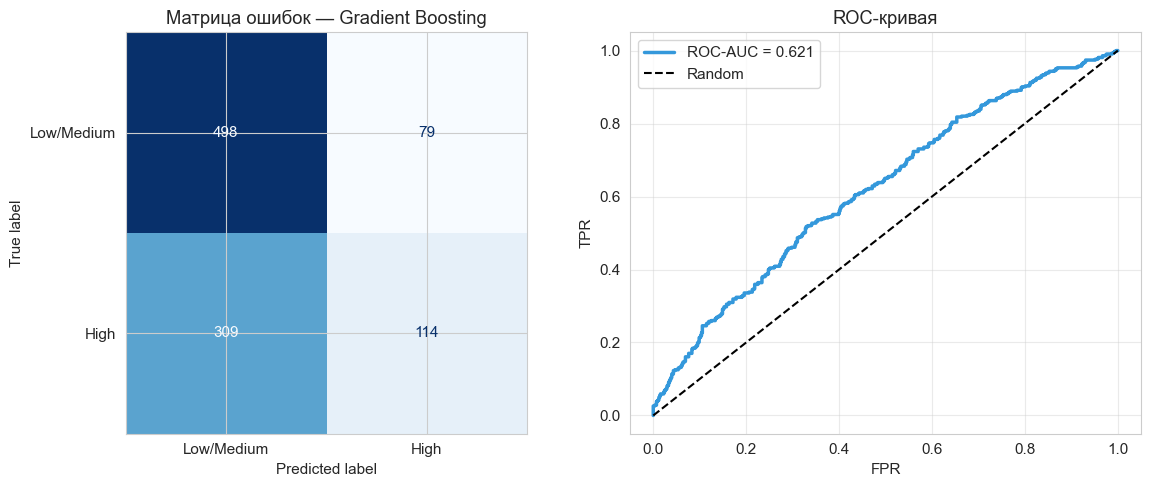

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Матрица ошибок
cm = confusion_matrix(y_test, y_pred_final)
ConfusionMatrixDisplay(cm, display_labels=['Low/Medium','High']).plot(
    ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Матрица ошибок — Gradient Boosting')

# ROC-кривая
fpr, tpr, _ = roc_curve(y_test, y_proba_final)
ra = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='#3498db', lw=2.5, label=f'ROC-AUC = {ra:.3f}')
axes[1].plot([0,1],[0,1],'k--', lw=1.5, label='Random')
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title('ROC-кривая'); axes[1].legend(); axes[1].grid(alpha=0.4)
plt.tight_layout(); plt.show()


## 6. Важность признаков


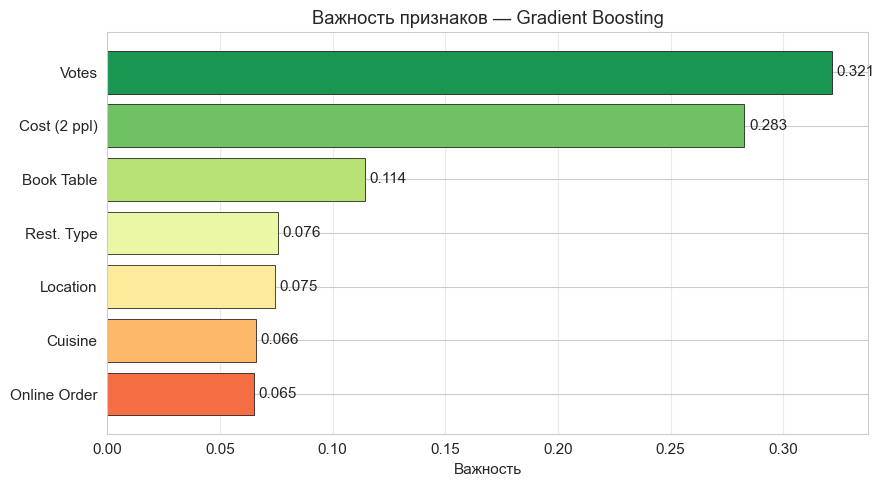

Топ-3 признака:
  Votes: 0.3215
  Cost (2 ppl): 0.2827
  Book Table: 0.1145


In [10]:
feat_labels = ['Online Order','Book Table','Votes','Cost (2 ppl)',
               'Location','Rest. Type','Cuisine']
fi = pd.Series(best_model.feature_importances_, index=feat_labels).sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(fi)))
bars = ax.barh(fi.index, fi.values, color=colors, edgecolor='black', lw=0.5)
for b, v in zip(bars, fi.values):
    ax.text(v+0.002, b.get_y()+b.get_height()/2, f'{v:.3f}', va='center')
ax.set_xlabel('Важность'); ax.set_title('Важность признаков — Gradient Boosting')
ax.grid(axis='x', alpha=0.4); plt.tight_layout(); plt.show()

print('Топ-3 признака:')
for feat, imp in fi.sort_values(ascending=False)[:3].items():
    print(f'  {feat}: {imp:.4f}')


## 7. Сохранение модели


In [11]:
model_bundle = {
    'model':       best_model,
    'scaler':      scaler,
    'le_loc':      le_loc,
    'le_rt':       le_rt,
    'le_cui':      le_cui,
    'features':    features,
    'locations':   list(le_loc.classes_),
    'rest_types':  list(le_rt.classes_),
    'cuisines':    list(le_cui.classes_),
    'best_params': gs.best_params_,
}
with open('model.pkl', 'wb') as f:
    pickle.dump(model_bundle, f)
print('Модель сохранена в model.pkl')


Модель сохранена в model.pkl


## 8. Веб-приложение

Запуск Flask-приложения:
```bash
pip install flask scikit-learn numpy pandas
python app.py
# Открыть http://localhost:5000
```

**Функциональность:**
- Форма ввода параметров ресторана (тип, кухня, район, стоимость, голоса, онлайн-заказ, бронь)
- Предсказание: High (≥ 4.0) / Low-Medium (< 4.0)
- Вероятность обоих классов с визуальными шкалами
- Рекомендации по улучшению рейтинга
- REST API endpoint `/api/predict` для интеграции


## 9. Выводы

**Результаты:**  
- Лучшая модель: **Gradient Boosting** (ROC-AUC=0.6275, Accuracy=0.607)  
- Параметры: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}  

**Ключевые находки:**  
- Наиболее важный признак — **число голосов** (votes): рестораны с большим количеством оценок чаще имеют высокий рейтинг  
- **Тип ресторана** существенно влияет: Fine Dining и Cafe в среднем выше 4.0  
- **Стоимость** умеренно связана с рейтингом — дорогие заведения не всегда лучше  
- **Онлайн-заказ** и **бронирование** дают небольшое, но стабильное преимущество  

**Рекомендации для ресторана:**  
- Активно собирать отзывы для увеличения числа голосов  
- Подключить онлайн-заказ и бронирование стола  
- Специализироваться на кухне с высоким средним рейтингом в районе  

**Ограничения:**  
- Синтетические данные сгенерированы на основе реальной структуры Zomato Dataset  
- Для повышения точности рекомендуется добавить текстовые признаки из отзывов (NLP)  
- Класс «High» имеет более низкий recall — возможна балансировка через `class_weight`
